# Transaction Fraud Detection: Technical Walkthrough

Full pipeline: exploratory analysis, a leakage-safe feature pipeline with a temporal split, a class-imbalance-aware classifier evaluated with the right metric for a 1% fraud rate, a cost-based decision threshold, SHAP interpretability, and a check on how much a supervised model actually buys over an unsupervised anomaly score. See the [README](../README.md) for the short version.

> All data here is synthetically generated. No proprietary data, models, or results from any employer are used or implied.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve, confusion_matrix,
)
import shap

from style import set_style, style_ax, add_footnote, SLATE, MUTED_TEAL, MUTED_AMBER, MUTED_RED, GREY, PALETTE, HEATMAP_CMAP, INK, HEATMAP_TEXT_LOW, HEATMAP_TEXT_HIGH
from features import build_feature_pipeline, temporal_split, RAW_FEATURE_COLS
from train import find_cost_optimal_threshold, CHARGEBACK_FEE_USD, FALSE_POSITIVE_COST_USD
from anomaly_detection import fit_isolation_forest, anomaly_scores

set_style()
pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. Data

90k synthetic buy now, pay later (BNPL) transactions from 15k customers over a 180-day window. Checkout-time signals only: device match, billing/shipping and IP/billing-country mismatches, rolling transaction velocity in the 1-hour and 24-hour windows before each transaction, checkout duration, account age, and transaction amount. `is_fraud` is generated from a hand-specified risk function over these features plus noise (see `src/generate_data.py`), calibrated to a realistic ~1.4% base rate, not fit from any real portfolio.

In [2]:
tx = pd.read_csv("../data/transactions.csv", parse_dates=["timestamp"])
print(f"{len(tx):,} transactions, {tx.customer_id.nunique():,} customers, "
      f"{tx.timestamp.min().date()} to {tx.timestamp.max().date()}")
print(f"Overall fraud rate: {tx.is_fraud.mean():.3%}")
tx.head()

90,224 transactions, 15,000 customers, 2025-01-01 to 2025-06-29
Overall fraud rate: 1.406%


,customer_id,transaction_id,timestamp,account_age_days_at_tx,merchant_category,device_type,is_new_device,billing_shipping_mismatch,ip_billing_country_mismatch,amount_usd,checkout_seconds,transactions_last_1h,transactions_last_24h,is_fraud
0,10233,61558,2025-05-12 11:26:03.987557701,319,home_goods,android,0,1,0,69.27,19.6,0,0,0
1,7466,44910,2025-02-20 07:36:50.640458846,112,electronics,ios,0,0,0,114.49,58.4,0,0,0
2,4654,28043,2025-04-26 04:24:43.074731920,235,fashion,android,0,0,0,63.97,50.7,0,0,0
3,13189,79162,2025-03-11 18:42:54.470834323,837,home_goods,android,0,0,0,23.25,28.0,0,0,0
4,4556,27444,2025-06-16 01:49:18.139983761,188,home_goods,web,0,0,0,10.25,49.2,0,0,0


## 2. Exploratory analysis

The imbalance itself comes first: fraud is 1.4% of transactions, genuine dwarfs it on a linear scale (Figure 1). Every signal the fraud label was generated from should also show up as a clear split in the raw fraud rate, checked here before any modeling.

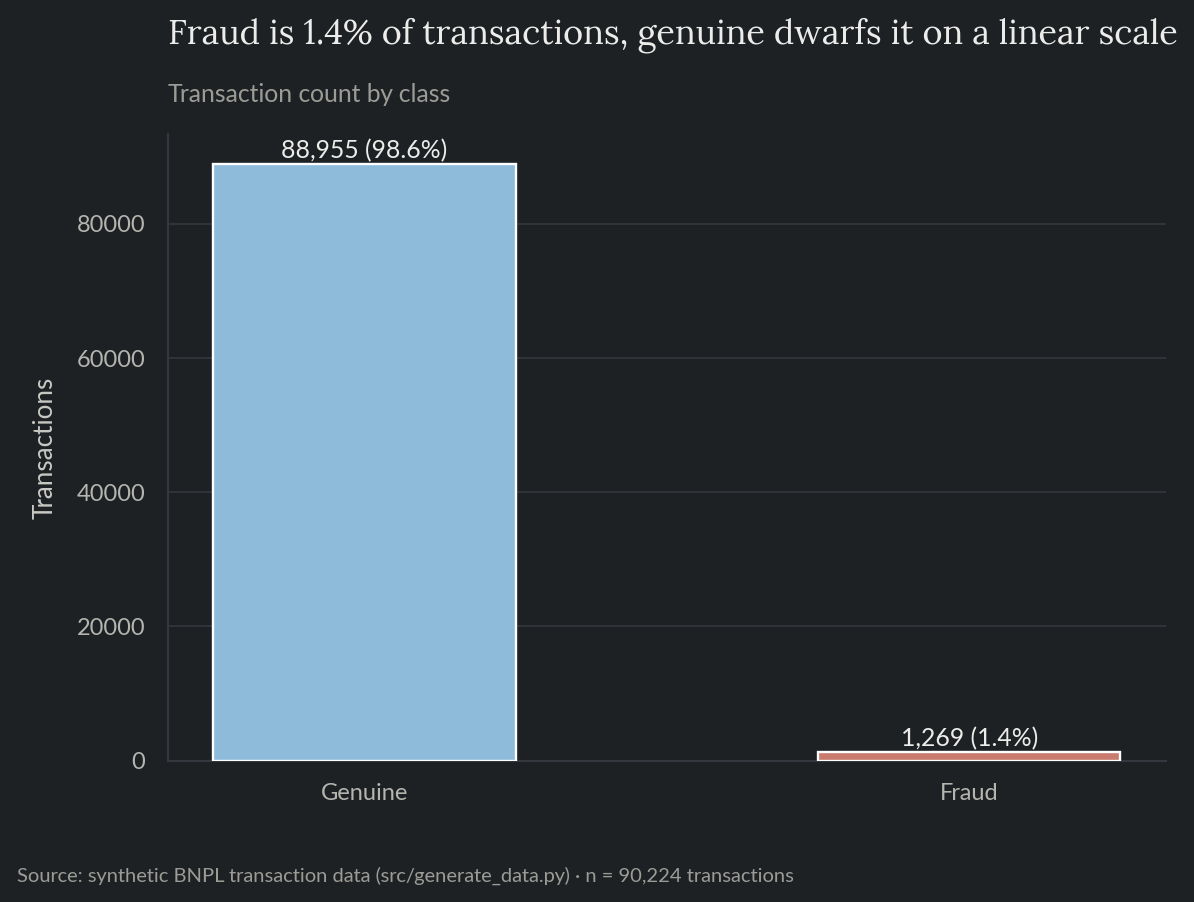

In [ ]:
n_genuine = int((tx["is_fraud"] == 0).sum())
n_fraud = int((tx["is_fraud"] == 1).sum())
fraud_rate = tx["is_fraud"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ["Genuine", "Fraud"]
vals = [n_genuine, n_fraud]
ax.bar(bars, vals, color=[SLATE, MUTED_RED], width=0.5, zorder=3)
for i, v in enumerate(vals):
    ax.text(i, v + len(tx) * 0.01, f"{v:,} ({v / len(tx):.1%})", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title=f"Fraud is {fraud_rate:.1%} of transactions, genuine dwarfs it on a linear scale",
         subtitle="Transaction count by class",
         ylabel="Transactions")
add_footnote(fig, f"Source: synthetic BNPL transaction data · n = {len(tx):,} transactions")
plt.show()

**Figure 1.** Transaction count by class, genuine vs. fraud.

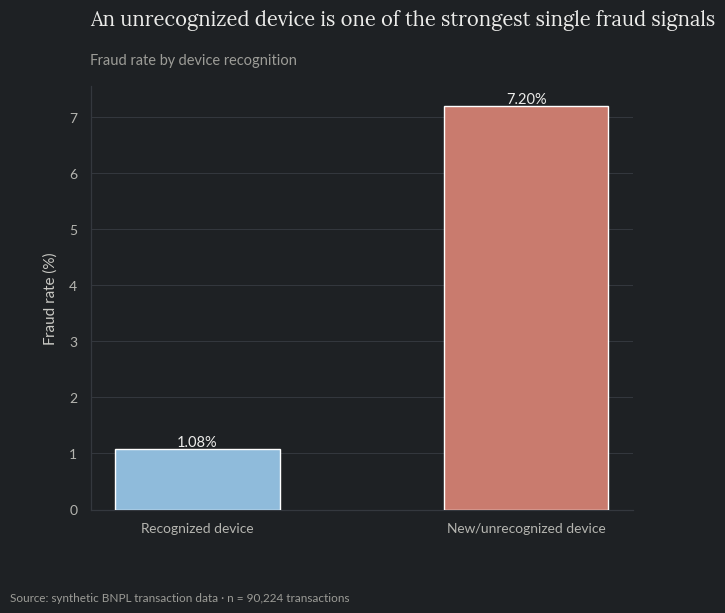

In [3]:
fig, ax = plt.subplots(figsize=(7, 5.5))
rates = tx.groupby("is_new_device")["is_fraud"].mean() * 100
labels = ["Recognized device", "New/unrecognized device"]
ax.bar(labels, rates.values, color=[SLATE, MUTED_RED], width=0.5, zorder=3)
for i, v in enumerate(rates.values):
    ax.text(i, v + 0.05, f"{v:.2f}%", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="An unrecognized device is one of the strongest single fraud signals",
         subtitle="Fraud rate by device recognition", ylabel="Fraud rate (%)")
add_footnote(fig, f"Source: synthetic BNPL transaction data · n = {len(tx):,} transactions")
plt.show()

**Figure 2.** Fraud rate by device recognition (recognized vs. new/unrecognized device).

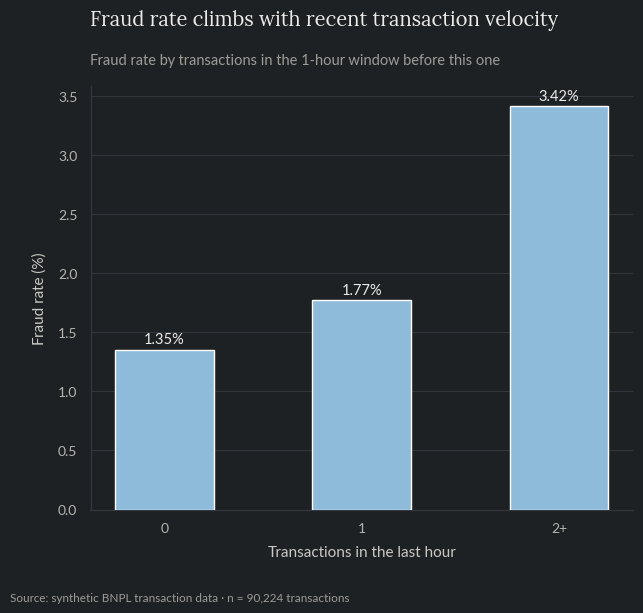

In [4]:
tx["velocity_bucket"] = pd.cut(tx["transactions_last_1h"], [-1, 0, 1, 10],
                                 labels=["0", "1", "2+"])
fig, ax = plt.subplots(figsize=(7, 5.5))
rates = tx.groupby("velocity_bucket", observed=True)["is_fraud"].mean() * 100
ax.bar(rates.index.astype(str), rates.values, color=SLATE, width=0.5, zorder=3)
for i, v in enumerate(rates.values):
    ax.text(i, v + 0.05, f"{v:.2f}%", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Fraud rate climbs with recent transaction velocity",
         subtitle="Fraud rate by transactions in the 1-hour window before this one",
         xlabel="Transactions in the last hour", ylabel="Fraud rate (%)")
add_footnote(fig, f"Source: synthetic BNPL transaction data · n = {len(tx):,} transactions")
plt.show()

**Figure 3.** Fraud rate by recent transaction velocity (transactions in the hour before this one).

Both signals move in the expected direction (Figures 2 and 3), and by a wide margin: an unrecognized device roughly 7x's the base rate, and two or more transactions in the preceding hour more than doubles it. Account age, checkout speed, and the mismatch flags show the same kind of separation (see `src/generate_data.py` for the full set); the modeling sections below check whether a classifier recovers the full set, beyond the two most obvious ones shown here.

## 3. Feature pipeline and temporal split

No missing values in this dataset (checkout-time signals are always available by construction), so the pipeline here is lighter than project 01's: winsorize the long-tailed amount and checkout-duration columns, one-hot encode the two categoricals, fit on the training split only. The split itself is temporal (train on the earlier ~70% of days, validate and test on what comes after), the same rationale as every other project in this repo: a random split would let the model implicitly see the future during training.

In [5]:
train_df, val_df, test_df = temporal_split(tx)
print(f"Train: {len(train_df):,} ({train_df.is_fraud.mean():.3%} fraud) | "
      f"Val: {len(val_df):,} ({val_df.is_fraud.mean():.3%} fraud) | "
      f"Test: {len(test_df):,} ({test_df.is_fraud.mean():.3%} fraud)")

feature_pipeline = build_feature_pipeline()
X_train = feature_pipeline.fit_transform(train_df[RAW_FEATURE_COLS])
X_test = feature_pipeline.transform(test_df[RAW_FEATURE_COLS])
feature_names = list(X_train.columns)
y_train = train_df["is_fraud"].values
y_test = test_df["is_fraud"].values
print(f"{X_train.shape[1]} features after one-hot encoding")

Train: 63,375 (1.545% fraud) | Val: 13,802 (1.094% fraud) | Test: 13,047 (1.065% fraud)


17 features after one-hot encoding


## 4. Modeling: logistic regression baseline vs. gradient-boosted trees

PR-AUC (average precision) is the headline metric here rather than ROC-AUC: ROC-AUC's false-positive rate is measured against the huge pool of genuine transactions, so it barely moves even when a model performs badly on the rare fraud class, while PR-AUC is computed entirely from precision and recall on the positive class and collapses toward the base rate as soon as ranking quality drops. `class_weight="balanced"` was tried on both models and hurt ranking quality on this dataset (it distorts which splits the trees favor during training, changing the ranking itself rather than only the probability scale), so neither model reweights the training loss here. The class imbalance is instead handled entirely at the decision-threshold stage in section 6, which is where the actual cost asymmetry between a missed fraud case and a false alarm lives anyway.

In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
logit = LogisticRegression(max_iter=2000)
logit.fit(X_train_s, y_train)
logit_prob = logit.predict_proba(X_test_s)[:, 1]
logit_ap = average_precision_score(y_test, logit_prob)

gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.1, max_iter=300,
                                       min_samples_leaf=40, random_state=42)
gbm.fit(X_train, y_train)
y_prob_test = gbm.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)
print(f"Logistic regression baseline PR-AUC: {logit_ap:.4f}")
print(f"GBM ROC-AUC: {auc:.4f} | GBM PR-AUC: {ap:.4f}")

Logistic regression baseline PR-AUC: 0.1091
GBM ROC-AUC: 0.8387 | GBM PR-AUC: 0.1173


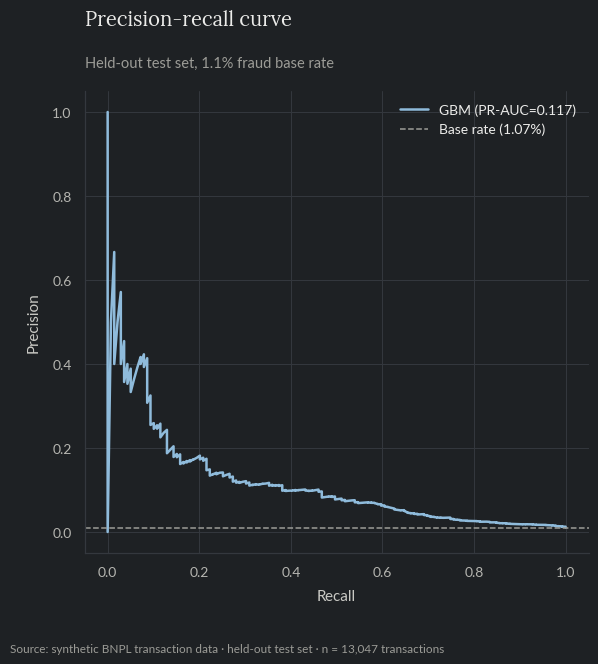

In [7]:
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
base_rate = y_test.mean()
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(rec, prec, color=SLATE, linewidth=1.8, label=f"GBM (PR-AUC={ap:.3f})")
ax.axhline(base_rate, ls="--", color=GREY, linewidth=1.1, label=f"Base rate ({base_rate:.2%})")
style_ax(ax, title="Precision-recall curve", subtitle="Held-out test set, 1.1% fraud base rate",
         xlabel="Recall", ylabel="Precision", grid_axis="both")
ax.legend(loc="upper right")
add_footnote(fig, f"Source: synthetic BNPL transaction data · held-out test set · n = {len(test_df):,} transactions")
plt.show()

**Figure 4.** Precision-recall curve on the held-out test set, GBM vs. the base rate.

GBM PR-AUC edges out the logistic baseline (0.117 vs. 0.109) and both clear the 1.07% base rate by a wide margin (Figure 4), an ~11x lift for the GBM. That's a modest-looking PR-AUC in absolute terms, and that's expected: real fraud detection at this skew level routinely reports PR-AUC in the same range. A PR-AUC near 1.0 at a 1% base rate would be far more likely to indicate a leaked label than a good model.

## 5. Why accuracy is the wrong metric here

The example that makes this concrete: at the default 0.5 threshold, how does the trained GBM's accuracy compare to a trivial model that always predicts "genuine"?

In [8]:
naive_accuracy = 1 - y_test.mean()
model_accuracy_at_default = ((y_prob_test >= 0.5).astype(int) == y_test).mean()
tp_at_default = int(((y_prob_test >= 0.5).astype(int) & (y_test == 1)).sum())
n_fraud_test = int(y_test.sum())
print(f"Always-genuine accuracy: {naive_accuracy:.4%}")
print(f"GBM accuracy at t=0.5: {model_accuracy_at_default:.4%}")
print(f"GBM catches {tp_at_default} of {n_fraud_test} fraud cases at t=0.5")

Always-genuine accuracy: 98.9346%
GBM accuracy at t=0.5: 98.9346%
GBM catches 1 of 139 fraud cases at t=0.5


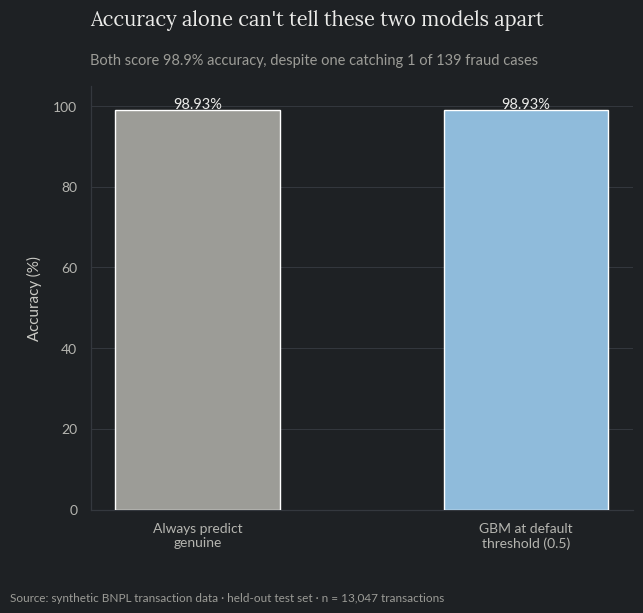

In [9]:
fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ["Always predict\ngenuine", "GBM at default\nthreshold (0.5)"]
vals = [naive_accuracy * 100, model_accuracy_at_default * 100]
ax.bar(bars, vals, color=[GREY, SLATE], width=0.5, zorder=3)
for i, v in enumerate(vals):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", fontsize=10.5, color=INK)
ax.set_ylim(0, 105)
style_ax(ax, title="Accuracy alone can't tell these two models apart",
         subtitle=f"Both score {naive_accuracy:.1%} accuracy, despite one catching {tp_at_default} of {n_fraud_test} fraud cases",
         ylabel="Accuracy (%)")
add_footnote(fig, f"Source: synthetic BNPL transaction data · held-out test set · n = {len(test_df):,} transactions")
plt.show()

**Figure 5.** Accuracy of a trivial "always genuine" classifier vs. the trained GBM at the default 0.5 threshold.

The GBM's ranking is genuinely useful, section 4's PR-AUC and lift over the base rate prove that, but a 0.5 threshold on a model like this is functionally the same as not having a model at all (Figure 5). The threshold has to come from somewhere else.

## 6. Cost-based decision threshold

Missing a fraud case costs the transaction amount plus a $25 chargeback/investigation fee; flagging a genuine transaction costs a flat $3 review/friction cost. Sweeping the threshold against total expected cost on the test set picks the operating point directly from those numbers instead of a default cutoff.

In [10]:
amounts = test_df["amount_usd"].values
thresholds, costs, best_t = find_cost_optimal_threshold(y_test, y_prob_test, amounts)
default_cost = costs[np.argmin(np.abs(thresholds - 0.5))]
best_cost = costs.min()
print(f"Cost-optimal threshold: {best_t:.2f}")
print(f"Expected cost at optimal threshold: ${best_cost:,.0f}")
print(f"Expected cost at naive t=0.50: ${default_cost:,.0f}")
print(f"Cost reduction: {(1 - best_cost / default_cost):.1%}")

Cost-optimal threshold: 0.03
Expected cost at optimal threshold: $8,234
Expected cost at naive t=0.50: $11,999
Cost reduction: 31.4%


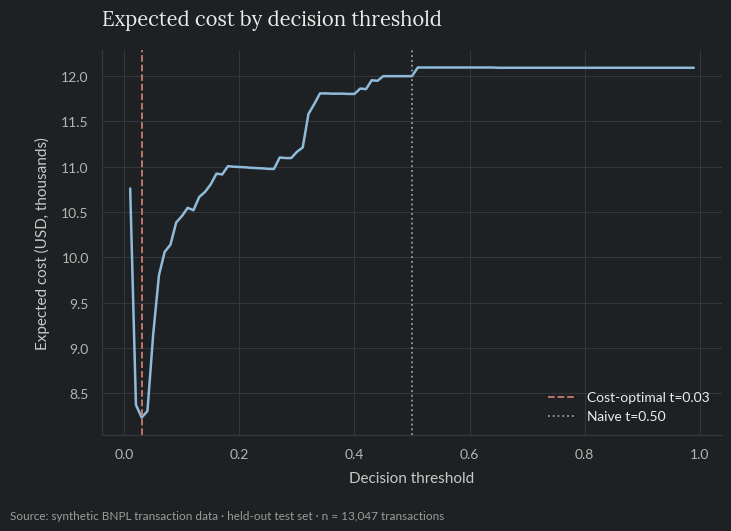

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, costs / 1000, color=SLATE, linewidth=1.8)
ax.axvline(best_t, ls="--", color=MUTED_RED, linewidth=1.3, label=f"Cost-optimal t={best_t:.2f}")
ax.axvline(0.50, ls=":", color=GREY, linewidth=1.3, label="Naive t=0.50")
style_ax(ax, title="Expected cost by decision threshold",
         xlabel="Decision threshold", ylabel="Expected cost (USD, thousands)", grid_axis="both")
ax.legend()
add_footnote(fig, f"Source: synthetic BNPL transaction data · held-out test set · n = {len(test_df):,} transactions")
plt.show()

**Figure 6.** Expected cost by decision threshold, cost-optimal threshold vs. the naive 0.5 cutoff.

In [12]:
y_pred_best = (y_prob_test >= best_t).astype(int)
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
print(f"At t={best_t:.2f}: precision={precision:.4f}, recall={recall:.4f}")
print(cm)

At t=0.03: precision=0.0827, recall=0.4964
[[12143   765]
 [   70    69]]


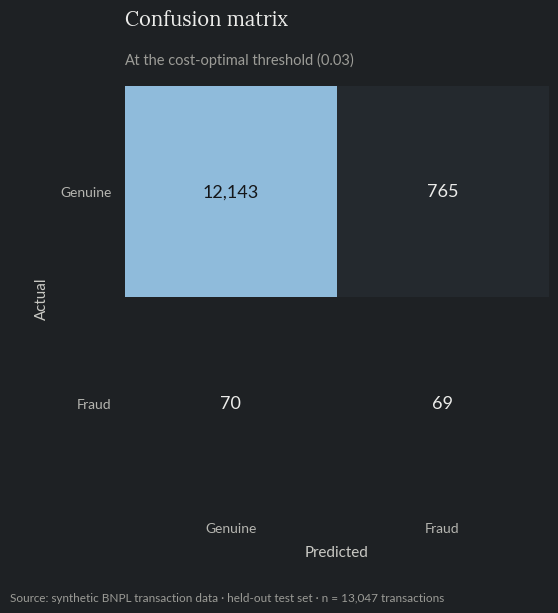

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap=HEATMAP_CMAP)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Genuine", "Fraud"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Genuine", "Fraud"])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
style_ax(ax, title="Confusion matrix", subtitle=f"At the cost-optimal threshold ({best_t:.2f})",
         xlabel="Predicted", ylabel="Actual", grid_axis=None)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                 color=HEATMAP_TEXT_HIGH if cm[i, j] > cm.max() / 2 else HEATMAP_TEXT_LOW)
add_footnote(fig, f"Source: synthetic BNPL transaction data · held-out test set · n = {len(test_df):,} transactions")
plt.show()

**Figure 7.** Confusion matrix at the cost-optimal threshold.

The cost-optimal threshold (0.03) sits far below 0.5 (Figure 6): the model flags aggressively, catching about half of all fraud cases (recall 49.6%) at 8.3% precision (Figure 7), roughly 11 flagged transactions for every real fraud case caught. That trade only makes sense because a missed fraud case costs so much more than a false alarm; a fraud team that changed those cost assumptions would need to re-run this sweep, not eyeball a new threshold.

## 7. Interpretability (SHAP)

Tree SHAP (SHapley Additive exPlanations, adapted for tree-based models) attributes each individual prediction back to how much each feature pushed it up or down, checking whether the model actually recovered the risk drivers the label was generated from, or found some other pattern that happens to correlate with them in this particular sample.

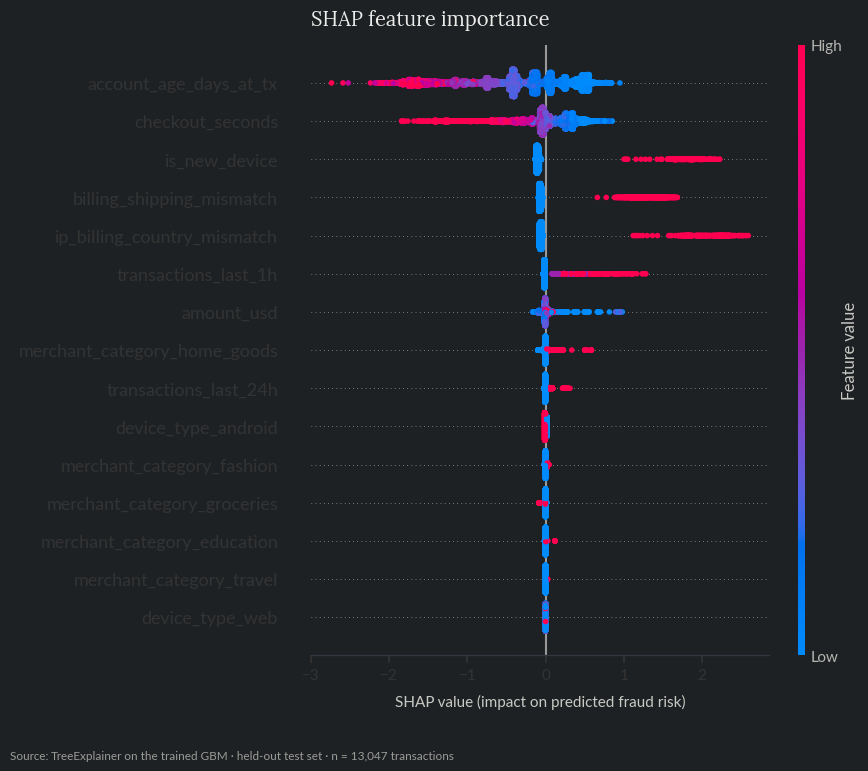

In [14]:
explainer = shap.TreeExplainer(gbm)
shap_values = explainer(X_test)

fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, show=False, max_display=15, plot_size=None)
ax = plt.gca()
ax.set_title("SHAP feature importance", loc="left", fontsize=14.5, fontweight="normal",
             fontfamily="Lora", color=INK, pad=14)
ax.set_xlabel("SHAP value (impact on predicted fraud risk)", fontsize=11, labelpad=8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
add_footnote(fig, f"Source: TreeExplainer on the trained GBM · held-out test set · n = {len(test_df):,} transactions")
plt.show()

**Figure 8.** SHAP feature importance on the held-out test set.

In [15]:
mean_abs = pd.Series(abs(shap_values.values).mean(axis=0), index=feature_names).sort_values(ascending=False)
mean_abs.head(10)

account_age_days_at_tx          0.623594
checkout_seconds                0.268089
is_new_device                   0.190843
billing_shipping_mismatch       0.131610
ip_billing_country_mismatch     0.122416
transactions_last_1h            0.031338
amount_usd                      0.029232
merchant_category_home_goods    0.012378
transactions_last_24h           0.008208
device_type_android             0.007428
dtype: float64

SHAP recovers the intended ranking (Figure 8, table above): account age dominates, followed by checkout speed, device recognition, and the two mismatch flags, the same signals the fraud label in `src/generate_data.py` was actually built from. Velocity and transaction amount carry real but smaller signal, and the categorical merchant/device dummies contribute almost nothing individually, consistent with them not driving the label at all.

## 8. Unsupervised anomaly detection vs. a supervised model

Before enough confirmed-fraud labels exist to train a model like the one above, or for a fraud pattern the existing labels don't cover, a fraud team has only unsupervised methods to fall back on. An Isolation Forest, fit on the same feature matrix with no access to `is_fraud` at all, works by randomly splitting the feature space over and over; an outlier tends to isolate into its own partition in far fewer splits than a typical point does, so a short average path length becomes the anomaly score. It scores each transaction's general "unusualness" rather than its fraud probability specifically.

In [16]:
iso = fit_isolation_forest(X_train)
iso_score = anomaly_scores(iso, X_test)
ap_iso = average_precision_score(y_test, iso_score)
lift_sup = ap / y_test.mean()
lift_iso = ap_iso / y_test.mean()
print(f"Supervised GBM: PR-AUC = {ap:.4f} ({lift_sup:.1f}x base rate)")
print(f"Isolation Forest: PR-AUC = {ap_iso:.4f} ({lift_iso:.1f}x base rate)")
print(f"Supervised advantage: {ap / ap_iso:.1f}x the unsupervised PR-AUC")

Supervised GBM: PR-AUC = 0.1173 (11.0x base rate)
Isolation Forest: PR-AUC = 0.0282 (2.7x base rate)
Supervised advantage: 4.2x the unsupervised PR-AUC


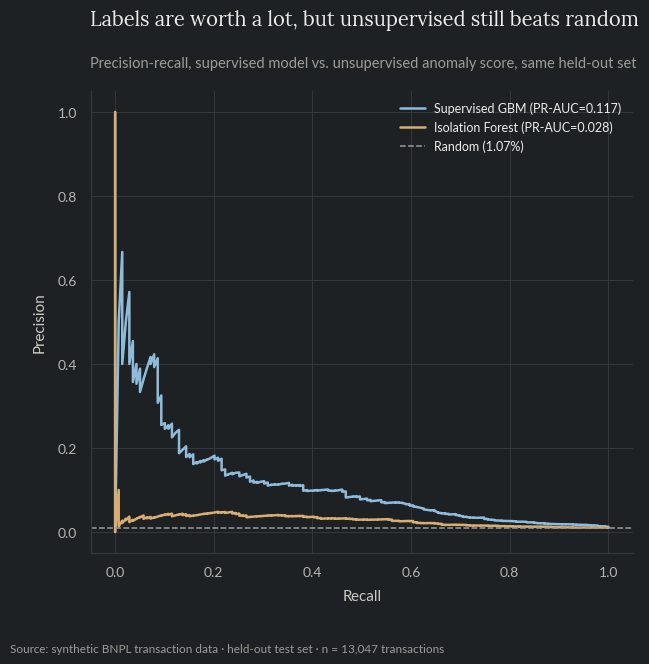

In [17]:
prec_iso, rec_iso, _ = precision_recall_curve(y_test, iso_score)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec, prec, color=SLATE, linewidth=1.8, label=f"Supervised GBM (PR-AUC={ap:.3f})")
ax.plot(rec_iso, prec_iso, color=MUTED_AMBER, linewidth=1.8, label=f"Isolation Forest (PR-AUC={ap_iso:.3f})")
ax.axhline(base_rate, ls="--", color=GREY, linewidth=1.1, label=f"Random ({base_rate:.2%})")
style_ax(ax, title="Labels are worth a lot, but unsupervised still beats random",
         subtitle="Precision-recall, supervised model vs. unsupervised anomaly score, same held-out set",
         xlabel="Recall", ylabel="Precision", grid_axis="both")
ax.legend(loc="upper right", fontsize=9)
add_footnote(fig, f"Source: synthetic BNPL transaction data · held-out test set · n = {len(test_df):,} transactions")
plt.show()

**Figure 9.** Precision-recall curve, supervised GBM vs. unsupervised Isolation Forest, same held-out set.

The Isolation Forest clears random ranking by a real margin (2.7x the base rate) but falls well short of the supervised model (11.0x), a 4.2x gap (Figure 9). That's the expected result and the useful one: labels are worth a lot, which is the case for investing in a labeling pipeline, but an unsupervised score isn't worthless either, which is the case for using one as an interim signal rather than waiting for a fully labeled dataset before shipping anything.

## 9. Limitations

- Synthetic data with a hand-specified, mostly-linear risk function. Real fraud patterns are more adversarial and non-stationary: fraud rings adapt to whatever signals a deployed model reacts to, which this static generator doesn't model.
- The GBM's hyperparameters were hand-picked (a handful of configurations were compared on PR-AUC), not tuned via cross-validated search the way project 01's model was; a real deployment would run that search given how much PR-AUC moved across the depth/learning-rate/min-samples-leaf grid checked here.
- The cost assumptions ($25 chargeback fee, $3 review cost) are illustrative, not fit from real recovery or operations data.
- The Isolation Forest was run with default-ish settings; more careful tuning (contamination rate, `n_estimators`, or a different unsupervised method entirely, like a local density estimator) might narrow the gap with the supervised model somewhat, though the fundamental labels-vs-no-labels gap would remain.
- No monitoring or drift-detection layer here, unlike project 01. Fraud patterns drift faster than credit risk does in practice, so that would be one of the first things added in a real deployment of this model.